# Projekt: Credit Card Customer Churn Prediction

**Ziel:** Abwandernde Kreditkarten-Kunden (`Attrition_Flag`) vorhersagen und ein **Ranking** der aktuell gefährdetsten Bestandskunden erstellen.

**Workflow:**
- Daten pflegen (Spalten bereinigen, fehlende Werte klären, Daten transformieren)
- Training: Train/Test Split **80/20** + **N-Fold Cross Validation**
- Auswertung: **Confusion Matrix**, **Precision / Recall / F1**
- Anwenden: Vorhersage & Ranking

## 1) Setup & Daten laden

**Voraussetzung:**
- Lege die Kaggle-Datei `BankChurners.csv` in den Ordner `dataset/`
  → Pfad: `dataset/BankChurners.csv`

👉 Direktlink: **https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers/data**


In [15]:
import sys
print(sys.executable)
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42

/Users/kapfi/Library/Mobile Documents/com~apple~CloudDocs/Workspace/CreditCardFraud/.venv/bin/python


In [2]:
DATA_PATH = "dataset/BankChurners.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Datei nicht gefunden: {DATA_PATH}\n"
        "Lege BankChurners.csv in den Ordner 'dataset/' (oder passe DATA_PATH an)."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2) Erste Checks (EDA light)

Wir prüfen:
- Datentypen
- Zielvariable / Klassenverteilung
- potenzielle Problemspalten (ID, Leakage/Artefakte)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
TARGET_COL = "Attrition_Flag"
if TARGET_COL not in df.columns:
    raise KeyError(f"Spalte '{TARGET_COL}' nicht gefunden. Spalten: {list(df.columns)}")

df[TARGET_COL].value_counts(dropna=False)

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

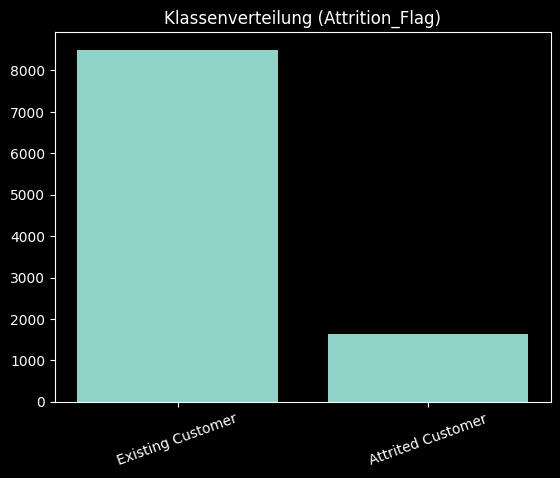

In [5]:
# Klassenanteile (Attrited vs Existing) - zur schnellen Kontrolle
counts = df[TARGET_COL].value_counts()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Klassenverteilung (Attrition_Flag)")
plt.xticks(rotation=20)
plt.show()

## 2b) Vollständige EDA: Plots für **alle** Variablen

Hier erzeugen wir für jede Variable einen passenden Plot:

- **Numerische Features**: Histogramm (gesamt + pro Klasse) + Boxplot nach Zielvariable  
- **Kategorische Features**: Häufigkeiten + Zielanteile (Existing vs. Attrited)

Optional speichern wir alle Plots in `outputs/eda_plots/`

Numerische Features: 14
Kategorische Features: 5
Leak/ID entfernt: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


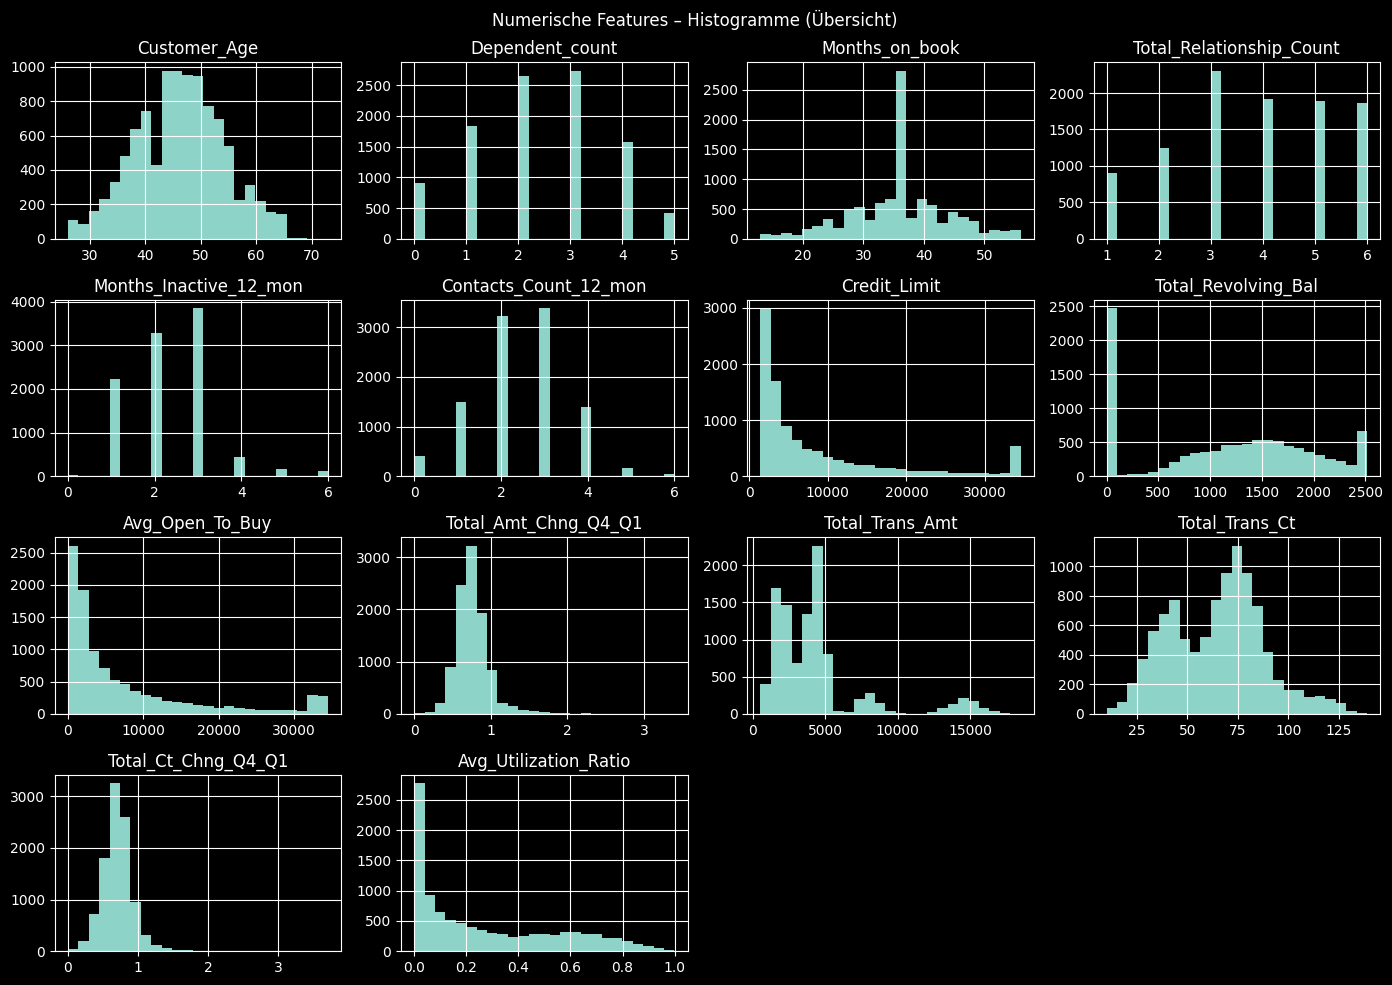

Plotte numerische Features: 14/14


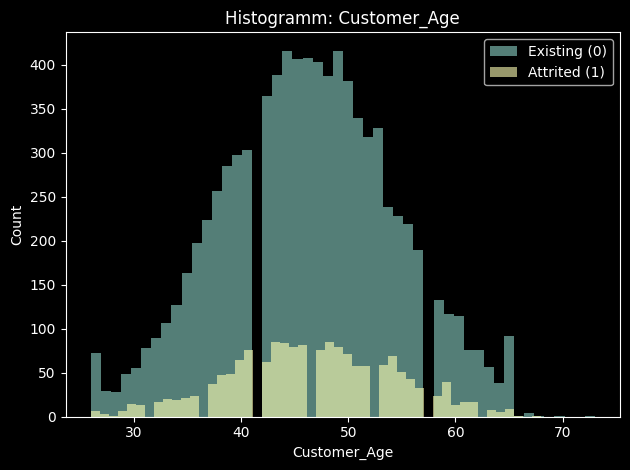

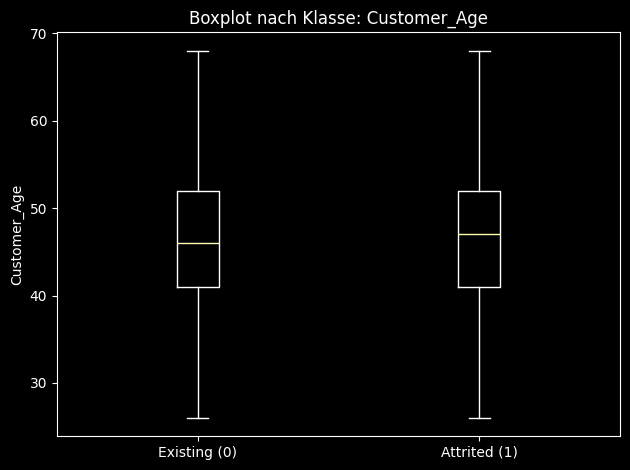

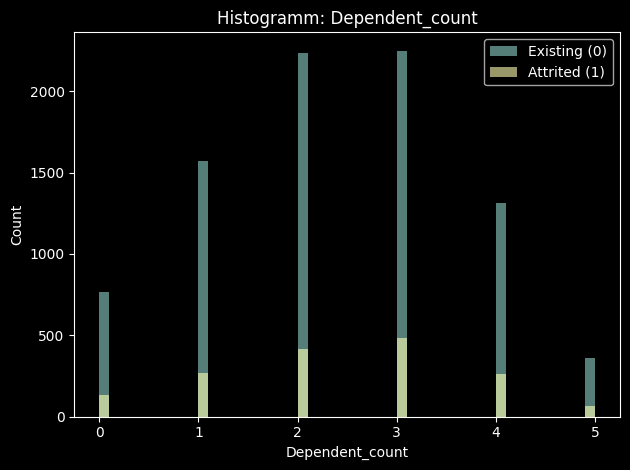

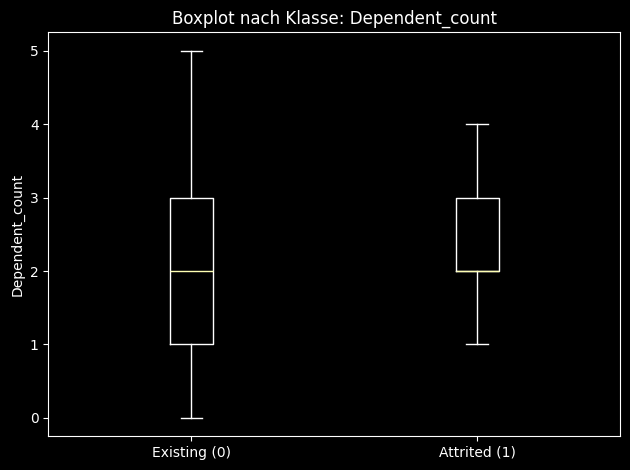

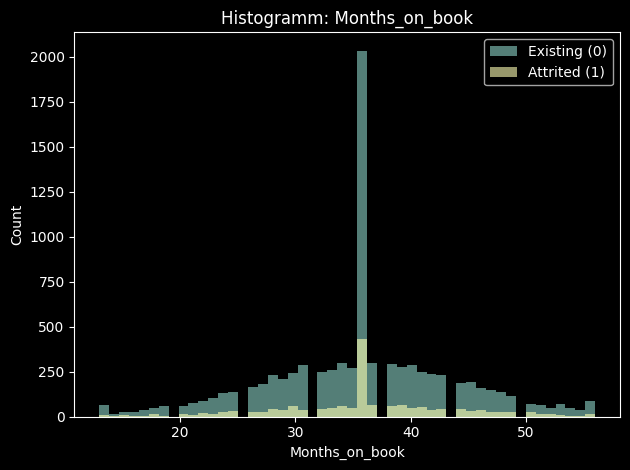

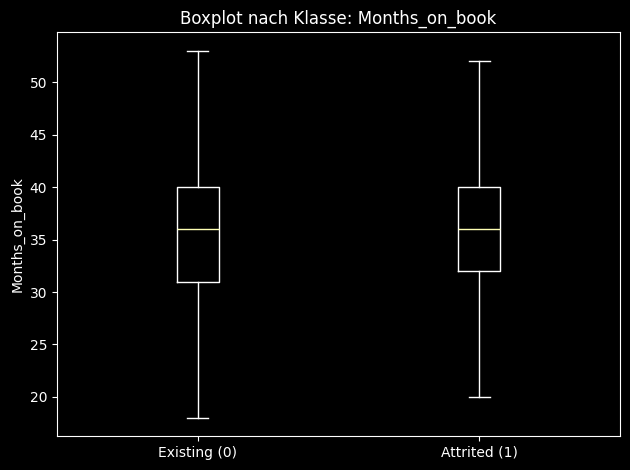

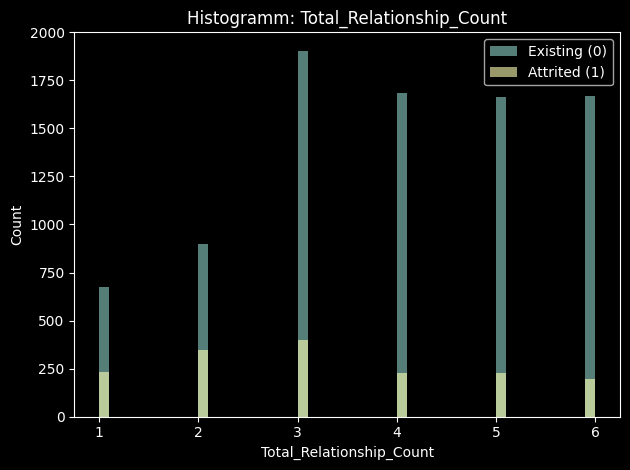

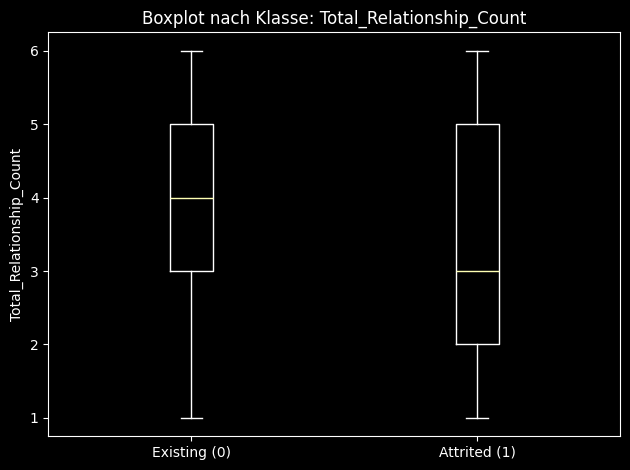

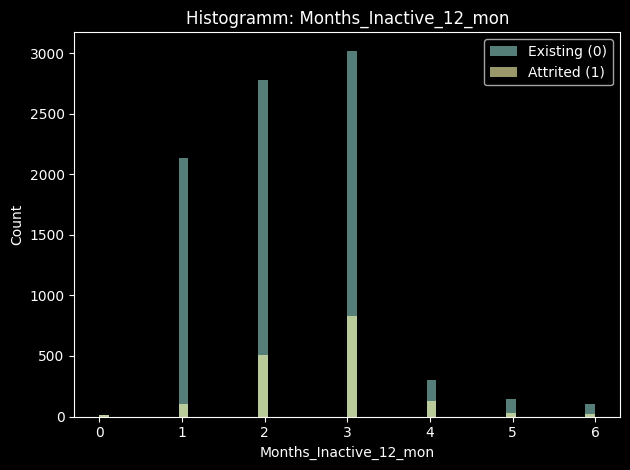

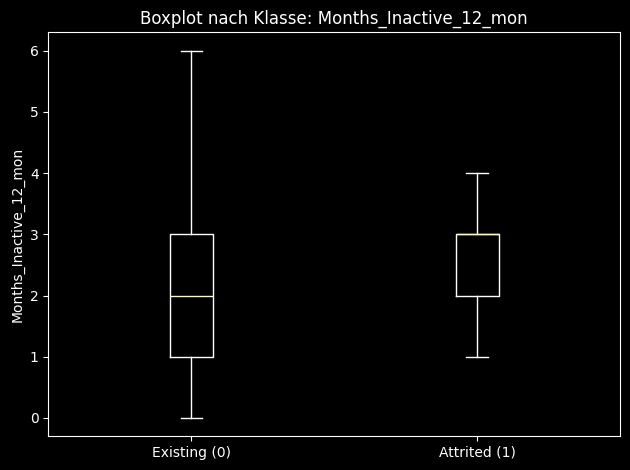

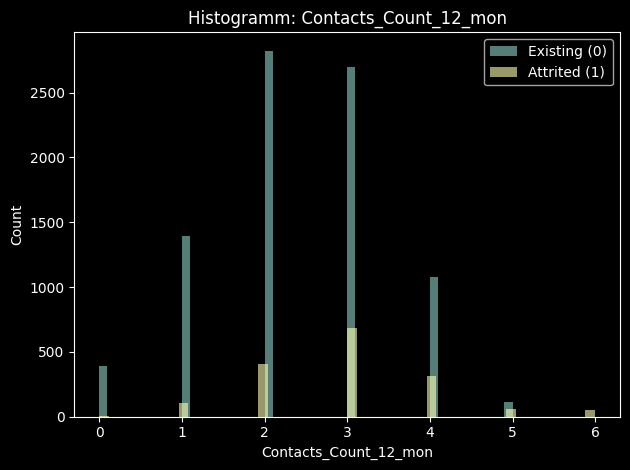

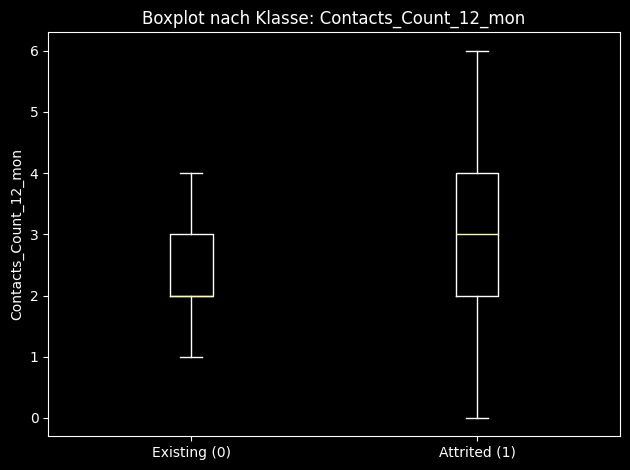

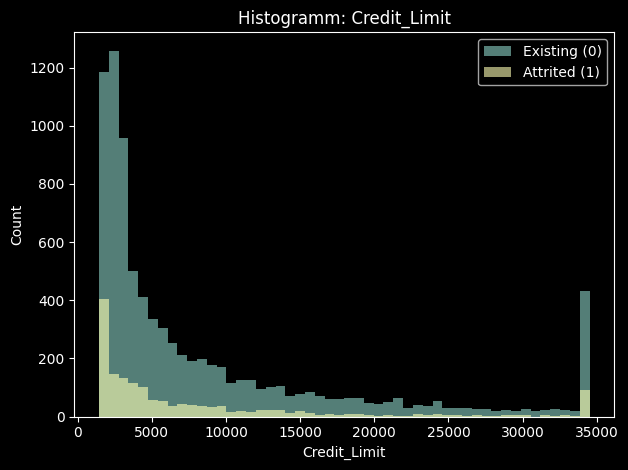

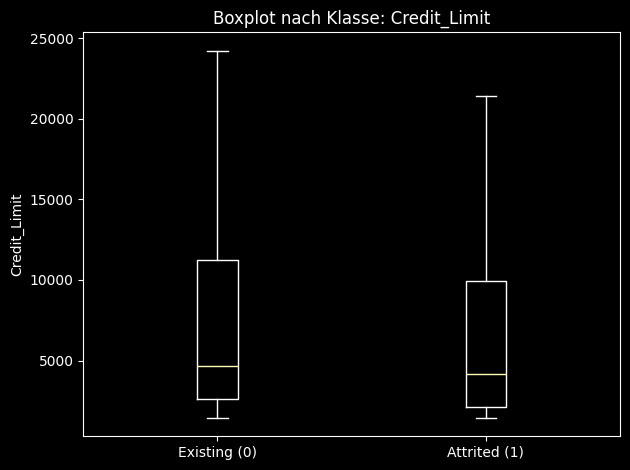

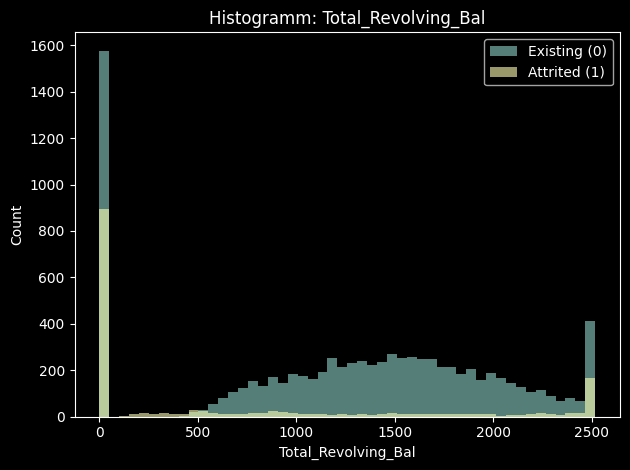

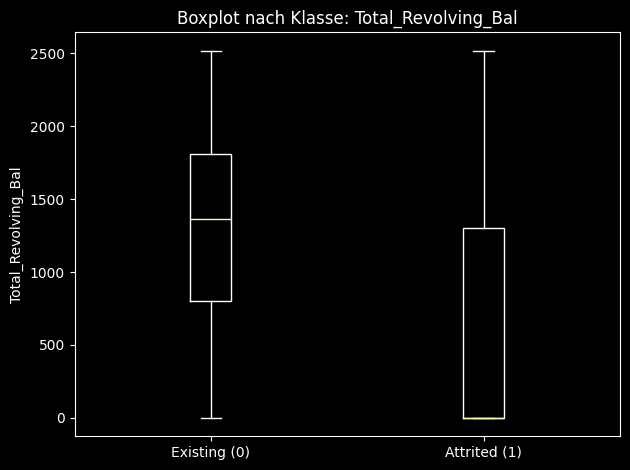

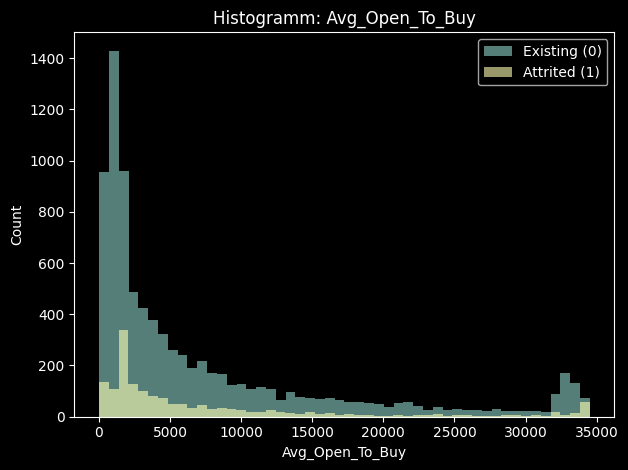

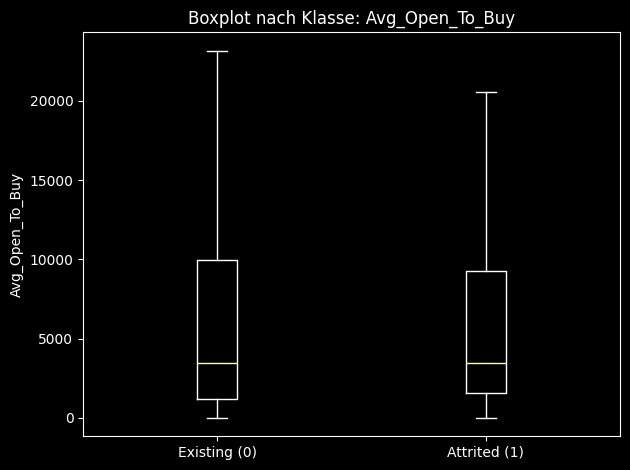

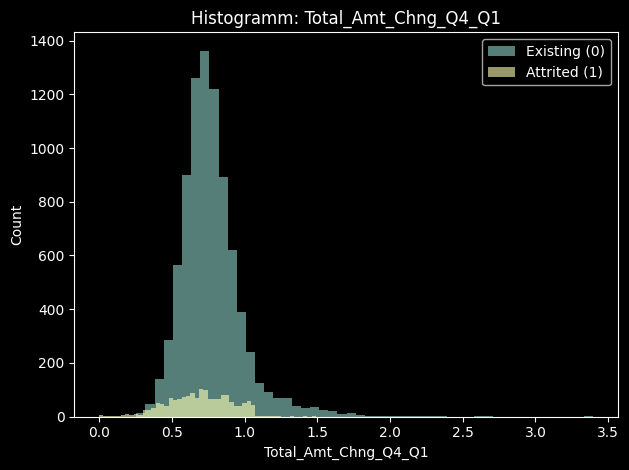

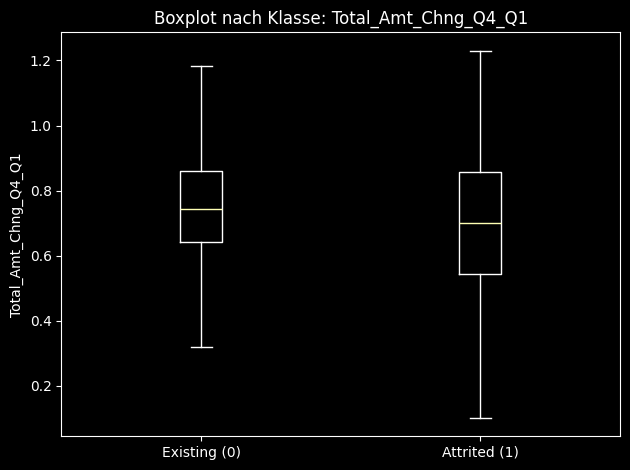

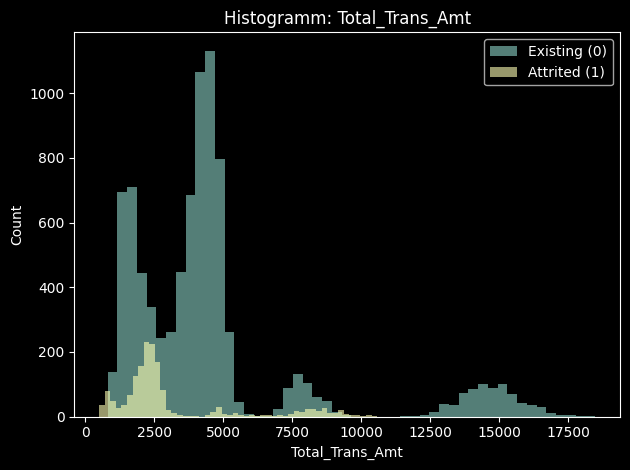

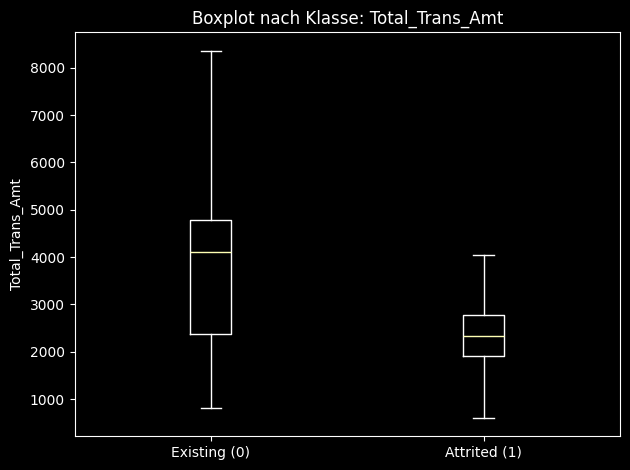

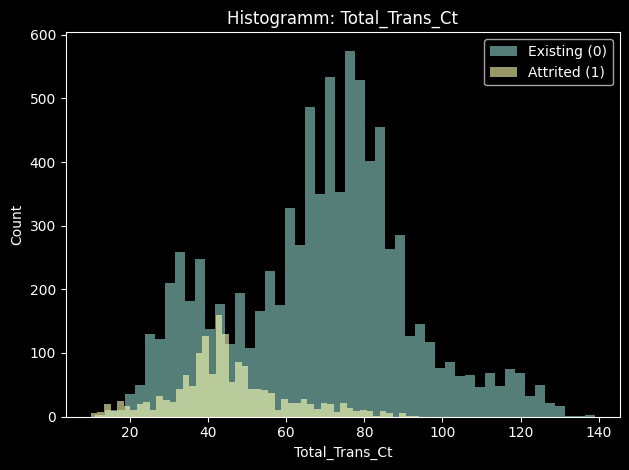

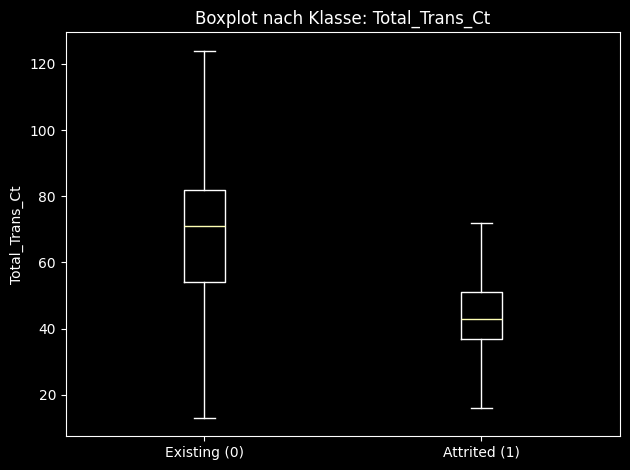

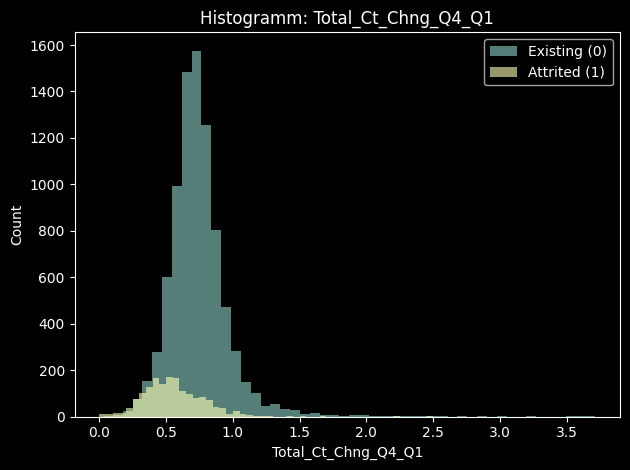

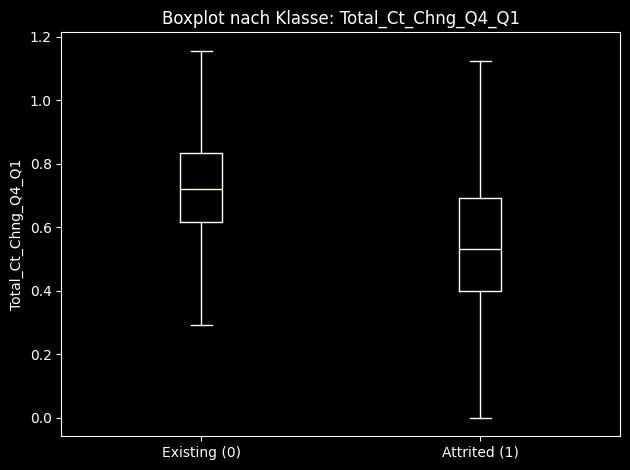

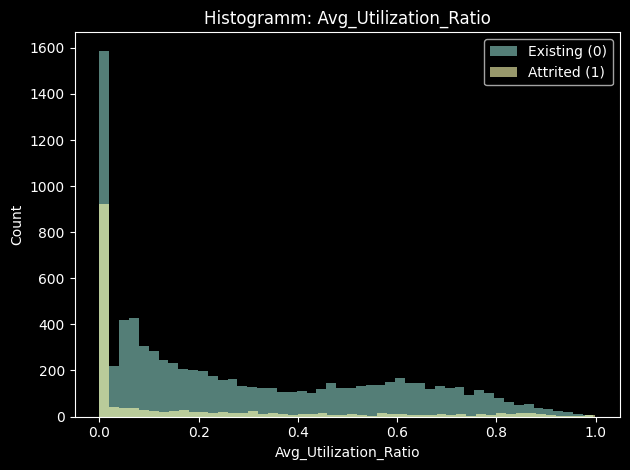

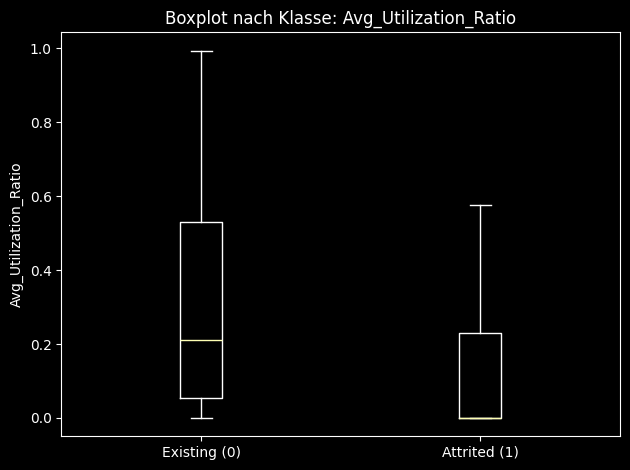

Plotte kategorische Features: 5/5


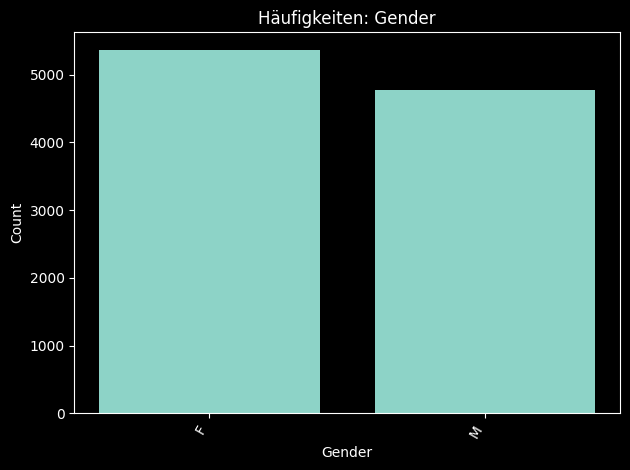

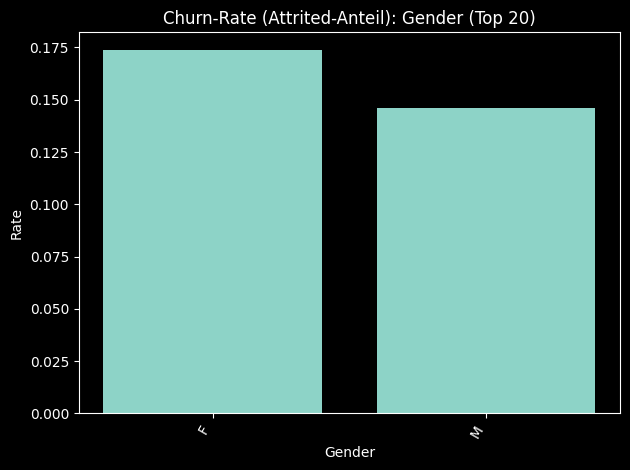

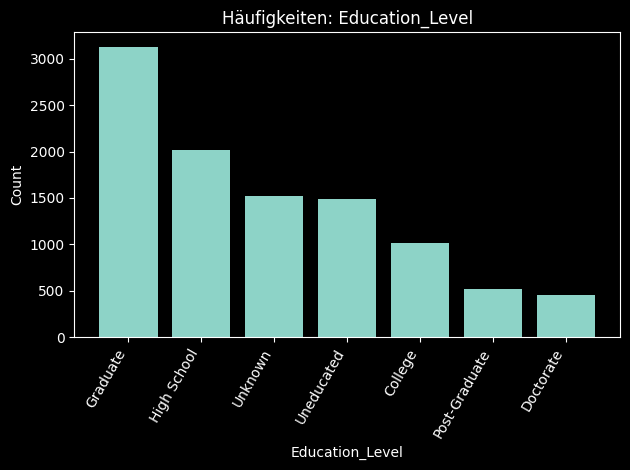

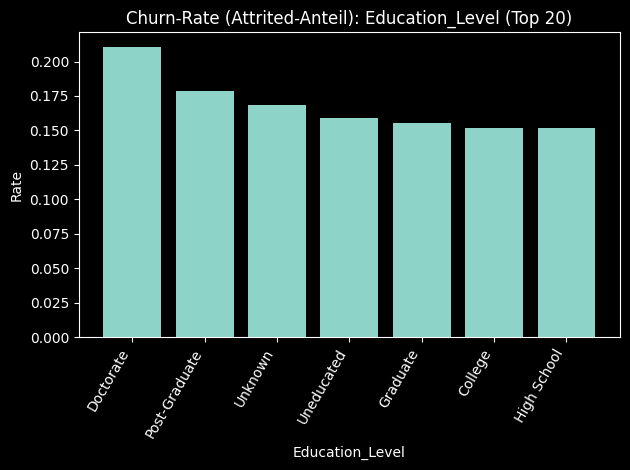

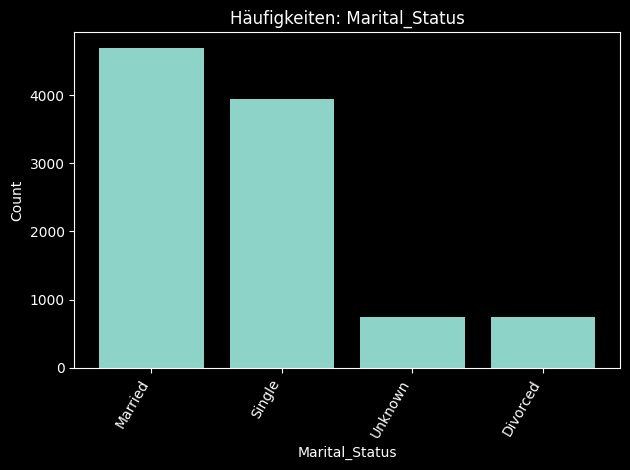

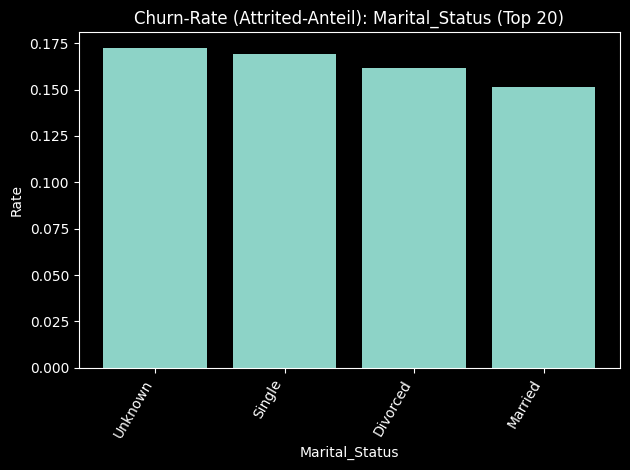

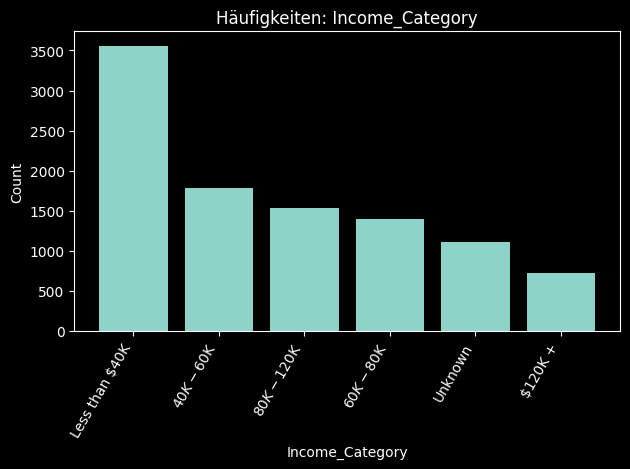

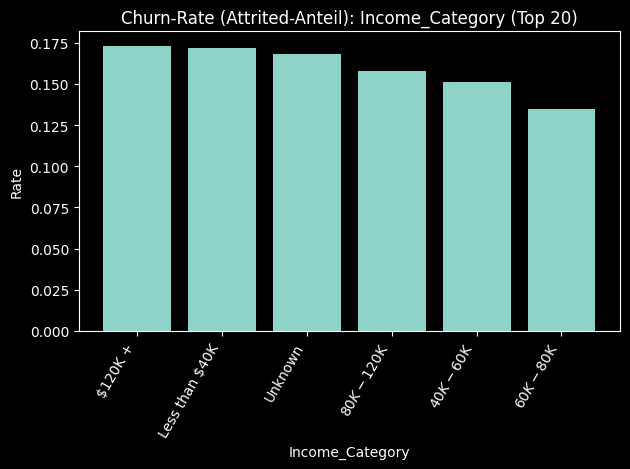

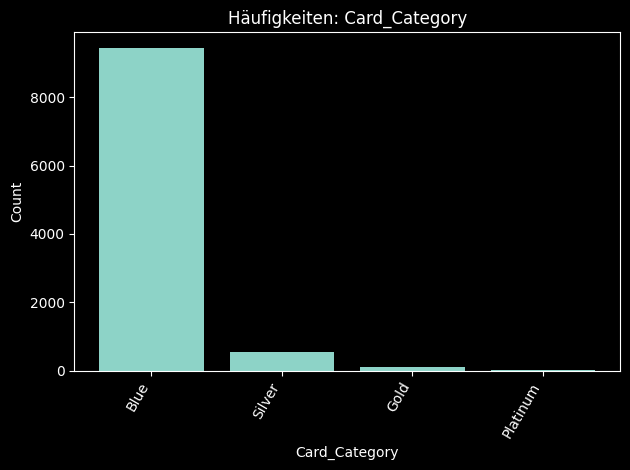

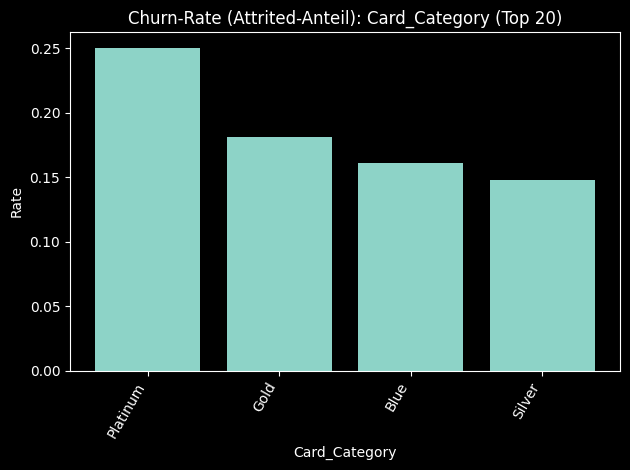

EDA-Plots fertig.


In [7]:
import re
TARGET_COL = "Attrition_Flag"

SAVE_PLOTS = True
PLOT_MAX_COLS = None   # None = wirklich alle; sonst z.B. 15 für schnelle Läufe

OUT_DIR = "outputs/eda_plots"
if SAVE_PLOTS:
    os.makedirs(OUT_DIR, exist_ok=True)

label_map = {
    "Existing Customer": 0,
    "Attrited Customer": 1,
    "Existing": 0,
    "Attrited": 1
}

y_raw = df[TARGET_COL].astype(str)
y_bin = y_raw.map(label_map)

if y_bin.isna().any():
    uniq = sorted(y_raw.unique().tolist())
    print("Unbekannte Labels in Attrition_Flag:", uniq)
    if len(uniq) == 2:
        tmp_map = {uniq[0]: 0, uniq[1]: 1}
        y_bin = y_raw.map(tmp_map)
        print("Fallback Mapping verwendet:", tmp_map)
    else:
        raise ValueError("Zielvariable hat nicht genau 2 Klassen – bitte prüfen!")

df_eda = df.copy()
df_eda["_target_bin"] = y_bin

drop_cols_eda = []
if "CLIENTNUM" in df_eda.columns:
    drop_cols_eda.append("CLIENTNUM")
leak_cols = [c for c in df_eda.columns if c.startswith("Naive_Bayes_Classifier_")]
drop_cols_eda += leak_cols

feature_cols = [c for c in df_eda.columns if c not in [TARGET_COL, "_target_bin"] + drop_cols_eda]

num_cols = df_eda[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Numerische Features:", len(num_cols))
print("Kategorische Features:", len(cat_cols))
print("Leak/ID entfernt:", drop_cols_eda)
def _safe_filename(name: str) -> str:
    name = re.sub(r"[^a-zA-Z0-9_\-]+", "_", str(name))
    return name[:180]

def plot_numeric_feature(df_in: pd.DataFrame, col: str, target_col: str = "_target_bin"):
    series = df_in[col]
    if series.dropna().empty:
        return

    plt.figure()
    vals0 = df_in.loc[df_in[target_col] == 0, col].dropna()
    vals1 = df_in.loc[df_in[target_col] == 1, col].dropna()

    try:
        bins = min(50, max(10, int(np.sqrt(series.dropna().shape[0]))))
    except Exception:
        bins = 30

    plt.hist(vals0, bins=bins, alpha=0.6, label="Existing (0)")
    plt.hist(vals1, bins=bins, alpha=0.6, label="Attrited (1)")
    plt.title(f"Histogramm: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(os.path.join(OUT_DIR, f"num_hist_{_safe_filename(col)}.png"), dpi=160)
    plt.show()

    plt.figure()
    data = [vals0.values, vals1.values]
    plt.boxplot(data, tick_labels=["Existing (0)", "Attrited (1)"], showfliers=False)
    plt.title(f"Boxplot nach Klasse: {col}")
    plt.ylabel(col)
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(os.path.join(OUT_DIR, f"num_box_{_safe_filename(col)}.png"), dpi=160)
    plt.show()

def plot_categorical_feature(df_in: pd.DataFrame, col: str, target_col: str = "_target_bin"):
    series = df_in[col].astype(str).fillna("NaN")
    if series.empty:
        return

    vc = series.value_counts(dropna=False)
    top_n = 20
    if len(vc) > top_n:
        top = vc.iloc[:top_n]
        other = vc.iloc[top_n:].sum()
        vc_plot = pd.concat([top, pd.Series({"Other": other})])
    else:
        vc_plot = vc

    plt.figure()
    plt.bar(vc_plot.index.astype(str), vc_plot.values)
    plt.title(f"Häufigkeiten: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(os.path.join(OUT_DIR, f"cat_counts_{_safe_filename(col)}.png"), dpi=160)
    plt.show()

    ctab = pd.crosstab(series, df_in[target_col], normalize="index")
    if 1 in ctab.columns:
        churn_rate = ctab[1].sort_values(ascending=False)
        churn_rate = churn_rate.iloc[:top_n]
        plt.figure()
        plt.bar(churn_rate.index.astype(str), churn_rate.values)
        plt.title(f"Churn-Rate (Attrited-Anteil): {col} (Top {top_n})")
        plt.xlabel(col)
        plt.ylabel("Rate")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(os.path.join(OUT_DIR, f"cat_churnrate_{_safe_filename(col)}.png"), dpi=160)
        plt.show()

if num_cols:
    _ = df_eda[num_cols].hist(figsize=(14, 10), bins=25)
    plt.suptitle("Numerische Features – Histogramme (Übersicht)")
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(os.path.join(OUT_DIR, "num_hist_overview_grid.png"), dpi=160)
    plt.show()

to_plot_num = num_cols if PLOT_MAX_COLS is None else num_cols[:PLOT_MAX_COLS]
to_plot_cat = cat_cols if PLOT_MAX_COLS is None else cat_cols[:PLOT_MAX_COLS]

print(f"Plotte numerische Features: {len(to_plot_num)}/{len(num_cols)}")
for col in to_plot_num:
    plot_numeric_feature(df_eda, col)

print(f"Plotte kategorische Features: {len(to_plot_cat)}/{len(cat_cols)}")
for col in to_plot_cat:
    plot_categorical_feature(df_eda, col)

print("EDA-Plots fertig.")

## 3) Datenbereinigung

**Typische Drops:**
- `CLIENTNUM` ist nur eine ID → raus
- `Naive_Bayes_Classifier_...` sind im Datensatz oft enthalten → **Leakage/Artefakte** → raus

**Zielvariable mappen:**
- `Existing Customer` → 0
- `Attrited Customer` → 1

In [8]:
df = df.copy()

mapping = {
    "Existing Customer": 0,
    "Attrited Customer": 1
}

df[TARGET_COL] = df[TARGET_COL].map(mapping)

if df[TARGET_COL].isna().any():
    bad = df.loc[df[TARGET_COL].isna(), TARGET_COL].unique()
    raise ValueError(f"Unerwartete Werte in {TARGET_COL}: {bad}")

df[TARGET_COL].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

In [9]:
drop_cols = []
if "CLIENTNUM" in df.columns:
    drop_cols.append("CLIENTNUM")

leak_cols = [c for c in df.columns if c.startswith("Naive_Bayes_Classifier_")]
drop_cols += leak_cols

print("Drop cols:", drop_cols)

X = df.drop(columns=drop_cols + [TARGET_COL])
y = df[TARGET_COL]
print("X shape:", X.shape, "| y shape:", y.shape)

Drop cols: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
X shape: (10127, 19) | y shape: (10127,)


## 4) Fehlende Werte prüfen

Wir zählen fehlende Werte je Spalte.  
Wenn keine fehlen → perfekt.

In [10]:
missing = X.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Series([], dtype: int64)

## 5) Train/Test Split (80/20)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train churn-rate:", float(y_train.mean()))
print("Test  churn-rate:", float(y_test.mean()))

Train churn-rate: 0.1607208986544871
Test  churn-rate: 0.16041461006910168


## 6) Preprocessing

Wir bauen eine Pipeline, die:
- numerische Spalten: Median-Imputation + StandardScaler
- kategorische Spalten: häufigster Wert + OneHotEncoder

In [12]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerisch:", num_cols)
print("Kategorisch:", cat_cols)

Numerisch: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Kategorisch: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

## 7) Baseline-Modelle + N-Fold Cross Validation

Wir testen mehrere Modelle schnell per **Stratified K-Fold** und wählen das beste aus.
- Logistic Regression
- Decision Tree
- kNN

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "rf": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),
    "knn": KNeighborsClassifier(n_neighbors=15),
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "model": name,
        "precision_mean": np.mean(cv_out["test_precision"]),
        "recall_mean": np.mean(cv_out["test_recall"]),
        "f1_mean": np.mean(cv_out["test_f1"]),
    })

res_df = pd.DataFrame(results).sort_values("f1_mean", ascending=False)
res_df

,model,precision_mean,recall_mean,f1_mean
2,rf,0.924813,0.748096,0.827019
1,tree,0.807553,0.783442,0.794883
3,knn,0.860421,0.514636,0.643606
0,logreg,0.518918,0.847179,0.643440


## 8) Modell-Auswahl

Wir verwenden die sinnvollsten Kandidaten:
- Random Forest
- Logistic Regression

**Optimiert wird auf F1** (Balance aus Precision & Recall).

In [17]:
tree_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])

tree_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 20],
}

gs_tree = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
gs_tree.fit(X_train, y_train)

print("Tree best F1 (CV):", gs_tree.best_score_)
print("Tree best params:", gs_tree.best_params_)

Tree best F1 (CV): 0.8030968433270175
Tree best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [18]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )),
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features": ["sqrt", "log2"],
}

gs_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print("RF best F1:", gs_rf.best_score_)
print("RF best params:", gs_rf.best_params_)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced")),
])

logreg_grid = {
    "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
    "model__solver": ["liblinear", "lbfgs"],
}

gs_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
gs_logreg.fit(X_train, y_train)

print("LogReg best F1 (CV):", gs_logreg.best_score_)
print("LogReg best params:", gs_logreg.best_params_)

RF best F1 (CV): 0.8666731164460459
RF best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
LogReg best F1 (CV): 0.6480571880676467
LogReg best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}


## 9) Finales Modell bestimmen

Wir nehmen das Modell mit dem besseren CV-F1 und trainieren es final auf dem kompletten Trainingsset.

In [19]:
best_model = gs_tree.best_estimator_
best_name = "DecisionTree"
best_score = gs_tree.best_score_

if gs_logreg.best_score_ > best_score:
    best_model = gs_logreg.best_estimator_
    best_name = "LogisticRegression"
    best_score = gs_logreg.best_score_

if gs_rf.best_score_ > best_score:
    best_model = gs_rf.best_estimator_
    best_name = "RandomForest"
    best_score = gs_rf.best_score_

print("Final gewählt:", best_name, "| best F1:", best_score)
best_model.fit(X_train, y_train)

Final gewählt: RandomForest | best CV F1: 0.8666731164460459


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 10) Evaluation auf dem Testset

Ausgabe:
- Confusion Matrix
- Precision / Recall / F1
- Classification Report

In [20]:
y_pred = best_model.predict(X_test)

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

Precision: 0.8283132530120482
Recall   : 0.8461538461538461
F1       : 0.837138508371385

Classification Report:

              precision    recall  f1-score   support

           0      0.970     0.966     0.968      1701
           1      0.828     0.846     0.837       325

    accuracy                          0.947      2026
   macro avg      0.899     0.906     0.903      2026
weighted avg      0.948     0.947     0.947      2026



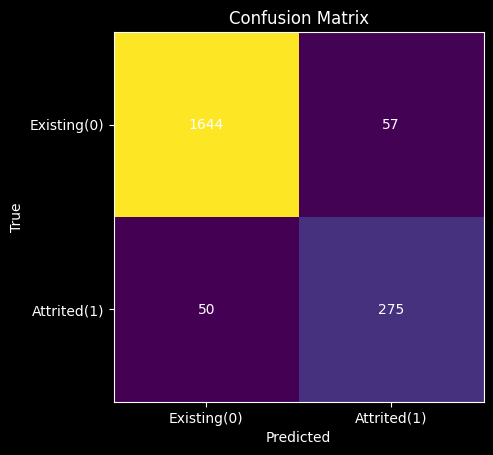

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["Existing(0)", "Attrited(1)"])
plt.yticks([0,1], ["Existing(0)", "Attrited(1)"])

# Zahlen in die Matrix schreiben
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha="center", va="center")

plt.show()

### Ergänzung: ROC- und Precision-Recall-Kurve + AUC

Neben der Confusion Matrix sind für binäre Klassifikation oft sinnvoll:
- **ROC-AUC** (Threshold-unabhängig)
- **PR-AUC / Average Precision** (hilfreich bei Klassenungleichgewicht)

ROC-AUC: 0.982035906480351
Average Precision (PR-AUC): 0.9274896037709194


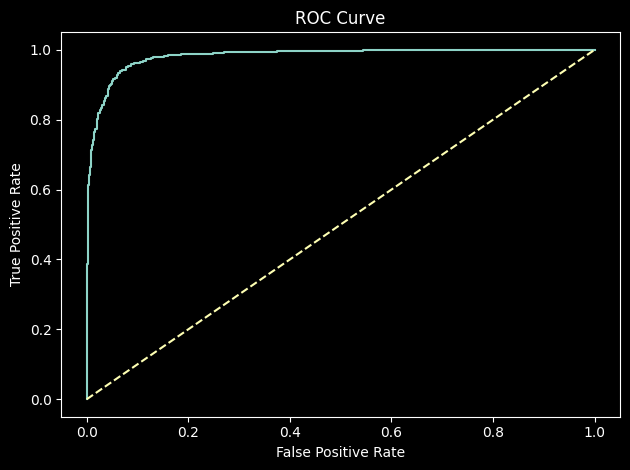

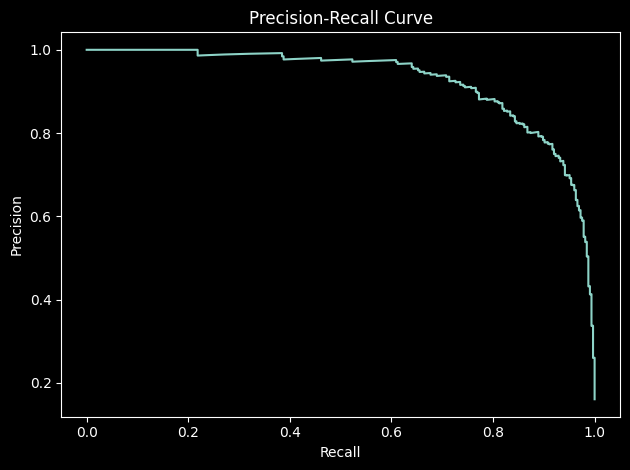

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)
    y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-9)

roc_auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)
print("Average Precision (PR-AUC):", ap)

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


## 11) Schwellenwert statt fixem 0.5

Standard ist 0.5. In der Praxis verwendet man oft:
- mehr Recall (weniger Abwanderer übersehen) **oder**
- mehr Precision (weniger „unnötig anschreiben“)

Wir suchen hier den Threshold, der den **F1** auf dem Testset maximiert.

In [23]:
if not hasattr(best_model, "predict_proba"):
    print("Dieses Modell unterstützt keine Wahrscheinlichkeiten (predict_proba).")
else:
    proba = best_model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.05, 0.95, 19)
    rows = []
    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": float(precision_score(y_test, pred_t, zero_division=0)),
            "recall": float(recall_score(y_test, pred_t, zero_division=0)),
            "f1": float(f1_score(y_test, pred_t, zero_division=0)),
        })

    thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
    thr_df.head(10)

## 12) Anwenden: Vorhersage & Ranking (Top-N gefährdete Kunden)

Wir berechnen für **alle** Kunden die Abwanderungs-Wahrscheinlichkeit und erstellen ein Ranking.

Output:
- `outputs/churn_ranking_top50.csv`

In [24]:
if not hasattr(best_model, "predict_proba"):
    raise RuntimeError("Ranking braucht predict_proba. Nimm z.B. LogReg/Tree/RandomForest.")

proba_all = best_model.predict_proba(X)[:, 1]

ranking = df.copy()
ranking["churn_proba"] = proba_all

if "CLIENTNUM" in df.columns:
    ranking["CLIENTNUM"] = df["CLIENTNUM"]

ranking_existing = ranking.copy()

cols = []
if "CLIENTNUM" in ranking_existing.columns:
    cols.append("CLIENTNUM")
cols += ["churn_proba", TARGET_COL]

top50 = (
    ranking_existing
    .sort_values("churn_proba", ascending=False)[cols]
    .head(50)
)

top50

,CLIENTNUM,churn_proba,Attrition_Flag
7974,711800658,0.999529,1
8186,712660308,0.998074,1
8294,772271508,0.997918,1
6384,815504583,0.997496,1
6304,809626983,0.996992,1
8379,779183958,0.996975,1
4262,799239033,0.996974,1
8208,711683358,0.996736,1
6913,717072108,0.996479,1
6810,719630358,0.996403,1


In [25]:
os.makedirs("outputs", exist_ok=True)
out_path = "outputs/churn_ranking_top50.csv"
top50.to_csv(out_path, index=False)
print("Gespeichert:", out_path)

Gespeichert: outputs/churn_ranking_top50.csv


## 13) Modell speichern

Wir speichern die komplette Pipeline (inkl. Preprocessing).

In [26]:
os.makedirs("models", exist_ok=True)
model_path = "models/churn_model.joblib"
joblib.dump(best_model, model_path)
print("Gespeichert:", model_path)

Gespeichert: models/churn_model.joblib
